# 06 - Model 5: Fine-tuned BERTweet
Fine-tune `vinai/bertweet-base` (Nguyen et al., 2020) for three-class vaccine-tweet stance (-1 / 0 / 1). BERTweet is a RoBERTa trained on 850M English tweets. A short validation-only check against COVID-Twitter-BERT (Muller et al., 2020) is optional at the end.

Tuning uses the validation split (macro-F1 to select, RMSE reported alongside). The final model is evaluated once on test. Every training run is appended to `reports/experiment_log.csv`.

| Exp | Question | Varied | Fixed |
|---|---|---|---|
| E1 | Does BERTweet prefer its own tweet format over the shared cleaner? | text: raw / clean | lr 2e-5, full fine-tune |
| E2 | Which fine-tuning learning rate works on this data? | 1e-5 / 2e-5 / 3e-5 | best E1 |
| E3 | Does inverse-frequency class weighting help the rare negative class? | class_weight on / off | best E2 |
| E4 | Is a frozen encoder enough, or does full fine-tuning help? | freeze + lr 1e-3 vs full fine-tune | best E3 |

`QUICK = True` runs one seed and two epochs. Set it to `False` for three seeds and five epochs.


In [1]:
import os, sys, tempfile, warnings, logging

# Quiet HF / torch before any transformers import.
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TQDM_DISABLE"] = "1"
warnings.filterwarnings("ignore", category=FutureWarning, module=r"torch(\.|$)")
warnings.filterwarnings("ignore", category=UserWarning, module=r"torch(\.|$)")
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub.utils._http").setLevel(logging.ERROR)

# Colab: mount Drive and use the project folder there. Local: use the repo root.
if "google.colab" in sys.modules:
    %pip install -q --progress-bar off emoji transformers
    from google.colab import drive
    drive.mount("/content/drive")
    BASE = "/content/drive/MyDrive/formative2-vaccine-sentiment"
    try:
        import transformers
        transformers.logging.set_verbosity_error()
    except Exception:
        pass
    try:
        from huggingface_hub.utils import disable_progress_bars
        disable_progress_bars()
    except Exception:
        pass
else:
    BASE = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()

for d in ["data/processed", "reports/figures", "reports/predictions", "models", "models/bertweet_ckpts"]:
    os.makedirs(os.path.join(BASE, d), exist_ok=True)
os.chdir(BASE)
sys.path.insert(0, BASE)
print("Working directory:", os.getcwd())


Mounted at /content/drive
Working directory: /content/drive/MyDrive/formative2-vaccine-sentiment


## Data, tokenizer and sequence length
The `raw` input keeps the original tweet wording but maps Zindi `<user>` / `<url>` to `@USER` / `HTTPURL`, which is how BERTweet was pretrained. The `clean` input uses the shared `clean_text` from the rest of the project. Sequences are capped at 80 tokens with dynamic padding to the longest tweet in each batch. The table below shows token-length stats used to choose that cap.


In [2]:
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display
from src.preprocessing import load_splits
from src.evaluation import evaluate, save_predictions, plot_history
from src.nn_utils import DEVICE, class_weights
from src.experiments import plot_sweep, history_table
from src.bert_utils import (
    BERT_UTILS_VERSION, BERTWEET_NAME, MAX_LEN, BertExperiments, BertStanceDataset,
    build_model, fit_bert, free_model, load_tokenizer, make_bert_loaders, predict_bert,
    texts_for_variant, token_length_stats, to_bertweet_raw,
)
assert BERT_UTILS_VERSION >= 3, (
    "Upload the current src/bert_utils.py to Drive and restart the runtime"
)

sns.set_theme(style="whitegrid")
AUTHOR, MODEL = "P3", "bertweet"

# QUICK=True runs one seed and two epochs. Set False for the full sweep.
QUICK = False
SEEDS = (42,) if QUICK else (42, 1, 2)
EPOCHS = 2 if QUICK else 5
BATCH = 16
LOG_PATH = (
    os.path.join(tempfile.gettempdir(), "bertweet_quick_experiment_log.csv")
    if QUICK else "reports/experiment_log.csv"
)
FIG = (
    tempfile.mkdtemp(prefix="bertweet_quick_fig_") + os.sep
    if QUICK else "reports/figures/"
)
CKPT_DIR = (
    tempfile.mkdtemp(prefix="bertweet_quick_ckpt_")
    if QUICK else "models/bertweet_ckpts"
)

if not QUICK and os.path.exists("reports/experiment_log.csv"):
    _prev = pd.read_csv("reports/experiment_log.csv")
    if "model" in _prev.columns and (_prev["model"] == "bertweet").any():
        raise SystemExit("Restore reports/experiment_log.csv from the repo before a full run")

print("Device:", DEVICE, "| QUICK:", QUICK, "| seeds:", SEEDS, "| epochs:", EPOCHS)
print("log_path:", LOG_PATH)
print("fig_dir:", FIG, "| ckpt_dir:", CKPT_DIR)
train, val, test = load_splits()
CW = class_weights(train)
print("splits", len(train), len(val), len(test))

tokenizer = load_tokenizer(BERTWEET_NAME)

# Sample raw inputs after mapping <user> and <url>.
examples = train.loc[train["safe_text"].str.contains(r"<user>|<url>", case=False, regex=True)].head(3)
if len(examples) < 3:
    examples = train.head(3)
print("Three tokenised raw examples:")
for _, row in examples.iterrows():
    raw = to_bertweet_raw(row["safe_text"])
    tokens = tokenizer.tokenize(raw)
    print("safe_text:", repr(row["safe_text"][:120]))
    print("raw input:", repr(raw[:120]))
    print("tokens:   ", tokens[:40], ("..." if len(tokens) > 40 else ""))
    print("---")

raw_stats = token_length_stats(tokenizer, texts_for_variant(train, "raw"), max_len=MAX_LEN)
clean_stats = token_length_stats(tokenizer, texts_for_variant(train, "clean"), max_len=MAX_LEN)
display(pd.DataFrame({"raw": raw_stats, "clean": clean_stats}).T.round(3))
print(f"max_len={MAX_LEN}: fraction over cap raw={raw_stats['frac_over_max_len']:.2%}, "
      f"clean={clean_stats['frac_over_max_len']:.2%}; "
      f"99th percentile raw={raw_stats['p99']:.0f}, clean={clean_stats['p99']:.0f}")


Device: cuda | QUICK: False | seeds: (42, 1, 2) | epochs: 5
log_path: reports/experiment_log.csv
fig_dir: reports/figures/ | ckpt_dir: models/bertweet_ckpts
splits 6689 1433 1434
Three tokenised raw examples:
safe_text: '#Vaccinations are important RT <user> Measles cases in California outbreak keep rising — now at almost 80. <url>'
raw input: '#Vaccinations are important RT @USER Measles cases in California outbreak keep rising — now at almost 80. HTTPURL'
tokens:    ['#V@@', 'acc@@', 'inations', 'are', 'important', 'RT', '@USER', 'Mea@@', 'sles', 'cases', 'in', 'California', 'outbreak', 'keep', 'rising', '—', 'now', 'at', 'almost', '80', '.', 'HTTPURL'] 
---
safe_text: 'Supporting LD471, an act to improve childhood vaccination rates in Maine. #vaccineswork <url>'
raw input: 'Supporting LD471, an act to improve childhood vaccination rates in Maine. #vaccineswork HTTPURL'
tokens:    ['Supporting', 'LD@@', '471', ',', 'an', 'act', 'to', 'improve', 'childhood', 'vaccination', 'rates', 'i

,n,mean,p50,p95,p99,max,frac_over_max_len
raw,6689.0,23.928,25.0,34.0,39.0,74.0,0.0
clean,6689.0,20.554,21.0,31.0,35.0,77.0,0.0


max_len=80: fraction over cap raw=0.00%, clean=0.00%; 99th percentile raw=39, clean=35


## Experiment runner
`train_bertweet(cfg, seed)` fine-tunes one config. `BertExperiments` runs each config over the seed list, logs every run, frees the model after each run, and saves the seed-42 weights to disk so the final cell can reload them.


In [3]:
def datasets_for_train_val(text_variant):
    """Build tokenised train and val datasets for one text variant."""
    tr_txt = texts_for_variant(train, text_variant)
    va_txt = texts_for_variant(val, text_variant)
    return (
        BertStanceDataset(tr_txt, train["label_id"], tokenizer, MAX_LEN),
        BertStanceDataset(va_txt, val["label_id"], tokenizer, MAX_LEN),
    )

DS = {v: datasets_for_train_val(v) for v in ("raw", "clean")}


def train_bertweet(cfg, seed, verbose=False):
    train_ds, val_ds = DS[cfg["text"]]
    train_dl, val_dl, _ = make_bert_loaders(
        train_ds, val_ds, test_ds=None, tokenizer=tokenizer, batch_size=BATCH, seed=seed,
    )
    model = build_model(BERTWEET_NAME, freeze_encoder=bool(cfg["freeze"]))
    hist, best = fit_bert(
        model, train_dl, val_dl, val["label"],
        epochs=EPOCHS, lr=cfg["lr"], weight_decay=0.01,
        class_weight_tensor=CW if cfg["class_weight"] else None,
        patience=2, clip=1.0, warmup=0.1, verbose=verbose,
    )
    return model, hist, best


def model_builder(cfg):
    return build_model(BERTWEET_NAME, freeze_encoder=bool(cfg["freeze"]))


ex = BertExperiments(
    train_bertweet, MODEL, author=AUTHOR, seeds=SEEDS,
    defaults=dict(text="raw", lr=2e-5, class_weight=False, freeze=False),
    ckpt_dir=CKPT_DIR,
    log_path=LOG_PATH,
)
print("defaults:", ex.best)


defaults: {'text': 'raw', 'lr': 2e-05, 'class_weight': False, 'freeze': False}


## E1: raw BERTweet text vs shared clean_text
BERTweet was pretrained on raw tweets with `@USER` and `HTTPURL`. This experiment checks whether that format beats the project's shared cleaner on validation macro-F1.


E1 | {'text': 'raw', 'lr': 2e-05, 'class_weight': False, 'freeze': False} | seed=42 | val F1 0.7298 | val RMSE 0.5255 | best_epoch 3
E1 | {'text': 'raw', 'lr': 2e-05, 'class_weight': False, 'freeze': False} | seed=1 | val F1 0.7261 | val RMSE 0.5196 | best_epoch 3
E1 | {'text': 'raw', 'lr': 2e-05, 'class_weight': False, 'freeze': False} | seed=2 | val F1 0.7263 | val RMSE 0.5514 | best_epoch 5
E1 | {'text': 'clean', 'lr': 2e-05, 'class_weight': False, 'freeze': False} | seed=42 | val F1 0.7250 | val RMSE 0.5230 | best_epoch 3
E1 | {'text': 'clean', 'lr': 2e-05, 'class_weight': False, 'freeze': False} | seed=1 | val F1 0.7308 | val RMSE 0.5401 | best_epoch 4
E1 | {'text': 'clean', 'lr': 2e-05, 'class_weight': False, 'freeze': False} | seed=2 | val F1 0.7261 | val RMSE 0.5626 | best_epoch 5


,text,val_macro_f1,f1_std,val_rmse,rmse_std,best_epoch,n_params
0,raw,0.7274,0.0021,0.5322,0.0169,3.6667,134902275
1,clean,0.7273,0.0031,0.5419,0.0198,4.0000,134902275


Winner leads the runner-up by 0.0001; seed std 0.0031 -> within seed noise
BEST (mean val macro-F1 0.7274): {'text': 'raw', 'lr': 2e-05, 'class_weight': False, 'freeze': False}


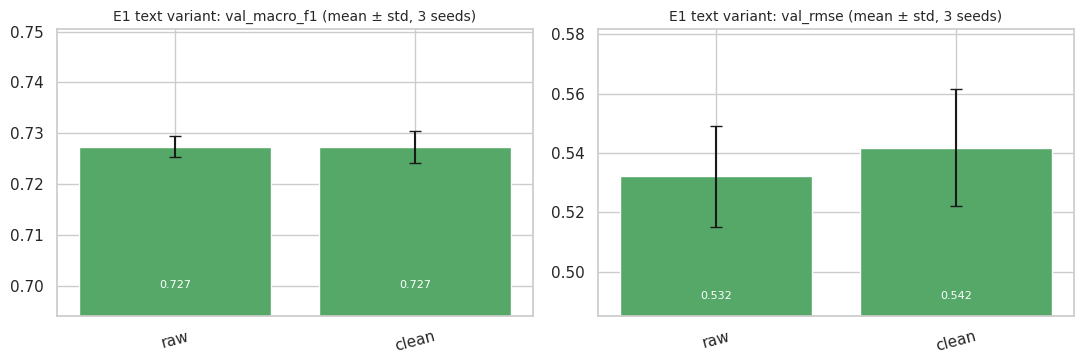

In [4]:
e1 = ex.sweep("E1", [dict(text="raw"), dict(text="clean")])
ex.update(e1, ["text"])
plot_sweep(e1.fillna({"f1_std": 0, "rmse_std": 0}), "text", "E1 text variant",
           FIG + "e1_bertweet_text.png", n_seeds=len(SEEDS), color="#55a868")


*Interpretation (E1):* there is no measurable difference between raw and clean text. Raw scores 0.7274 mean validation macro-F1 and clean scores 0.7273. The lead is 0.0001 and the seed std is 0.0031, so the gap is within seed noise. Raw is kept as the default.


## E2: learning rate
Fine-tuning is sensitive to the learning rate. This sweep compares 1e-5, 2e-5 and 3e-5 with the text variant from E1.


E2 | {'text': 'raw', 'lr': 1e-05, 'class_weight': False, 'freeze': False} | seed=1 | val F1 0.7120 | val RMSE 0.5287 | best_epoch 4
E2 | {'text': 'raw', 'lr': 1e-05, 'class_weight': False, 'freeze': False} | seed=2 | val F1 0.7092 | val RMSE 0.5510 | best_epoch 5
E2 | {'text': 'raw', 'lr': 3e-05, 'class_weight': False, 'freeze': False} | seed=42 | val F1 0.7145 | val RMSE 0.5836 | best_epoch 5
E2 | {'text': 'raw', 'lr': 3e-05, 'class_weight': False, 'freeze': False} | seed=1 | val F1 0.7387 | val RMSE 0.5263 | best_epoch 3
E2 | {'text': 'raw', 'lr': 3e-05, 'class_weight': False, 'freeze': False} | seed=2 | val F1 0.7359 | val RMSE 0.5137 | best_epoch 2


,lr,val_macro_f1,f1_std,val_rmse,rmse_std,best_epoch,n_params
0,1e-05,0.7105,0.0014,0.5428,0.0123,4.3333,134902275
1,2e-05,0.7274,0.0021,0.5322,0.0169,3.6667,134902275
2,3e-05,0.7297,0.0133,0.5412,0.0373,3.3333,134902275


Winner leads the runner-up by 0.0023; seed std 0.0133 -> within seed noise
BEST (mean val macro-F1 0.7297): {'text': 'raw', 'lr': 3e-05, 'class_weight': False, 'freeze': False}


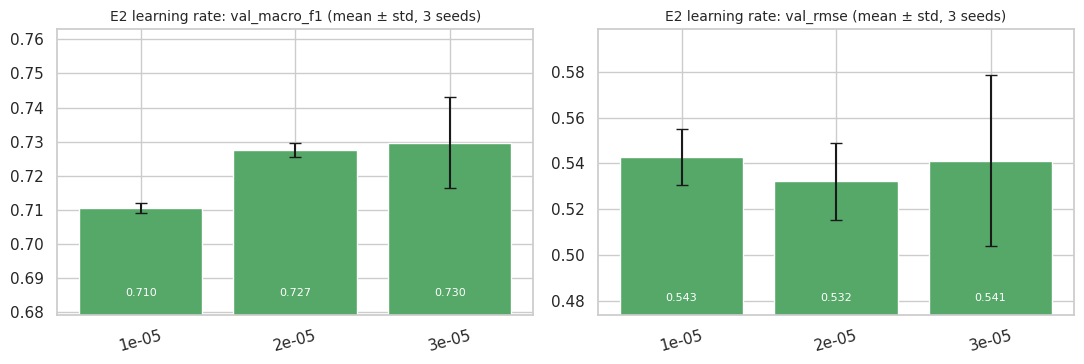

In [6]:
e2 = ex.sweep("E2", [dict(lr=1e-5), dict(lr=2e-5), dict(lr=3e-5)])
ex.update(e2, ["lr"])
plot_sweep(e2.fillna({"f1_std": 0, "rmse_std": 0}), "lr", "E2 learning rate",
           FIG + "e2_bertweet_lr.png", n_seeds=len(SEEDS), color="#55a868")


*Interpretation (E2):* learning rate 1e-5 is clearly lower at 0.7105 mean validation macro-F1. Rates 2e-5 (0.7274) and 3e-5 (0.7297) are within seed noise: the winner leads by 0.0023 against a seed std of 0.0133. The large spread at 3e-5 comes from one low seed. The printed run lines give seed 42 at 0.7145, seed 1 at 0.7387 and seed 2 at 0.7359. The best mean is 3e-5, so that learning rate is carried forward.


## E3: class-weighted loss
Negative tweets are the smallest class. This experiment turns inverse-frequency class weights on and off to see whether that helps validation macro-F1.


In [ ]:
e3 = ex.sweep("E3", [dict(class_weight=False), dict(class_weight=True)])
ex.update(e3, ["class_weight"])
plot_sweep(e3.fillna({"f1_std": 0, "rmse_std": 0}), "class_weight", "E3 class-weighted loss",
           FIG + "e3_bertweet_class_weight.png", n_seeds=len(SEEDS), color="#55a868")


E3 | {'text': 'raw', 'lr': 3e-05, 'class_weight': True, 'freeze': False} | seed=42 | val F1 0.7432 | val RMSE 0.5616 | best_epoch 5


*Interpretation (E3):* the E3 cell output is incomplete, so the means below are taken from reports/experiment_log.csv. Class-weighted loss has mean validation macro-F1 0.7389 (std 0.0038) and mean RMSE 0.5474 (std 0.0191). The unweighted runs at the same text and learning rate have mean validation macro-F1 0.7297 (std 0.0132) and mean RMSE 0.5412 (std 0.0373). The weighted mean is higher by 0.0092, but that lead is smaller than the seed std 0.0132, so the difference is within seed noise. The weighted runs varied less (F1 std 0.0038 against 0.0132). Class weighting is kept because it has the higher mean.


## E4: frozen encoder vs full fine-tune
A linear probe freezes the encoder and trains only the classification head at lr 1e-3. Full fine-tuning updates all weights at the learning rate from E2. This is a comparison of the two settings on validation; the best config from E1-E3 is left unchanged.


E4 | {'text': 'raw', 'lr': 0.001, 'class_weight': True, 'freeze': True} | seed=42 | val F1 0.5870 | val RMSE 0.6174 | best_epoch 4
E4 | {'text': 'raw', 'lr': 0.001, 'class_weight': True, 'freeze': True} | seed=1 | val F1 0.5815 | val RMSE 0.6473 | best_epoch 5
E4 | {'text': 'raw', 'lr': 0.001, 'class_weight': True, 'freeze': True} | seed=2 | val F1 0.5932 | val RMSE 0.6335 | best_epoch 5


,freeze,lr,val_macro_f1,f1_std,val_rmse,rmse_std,best_epoch,n_params
0,True,0.001,0.5872,0.0058,0.6327,0.015,4.6667,592899
1,False,3e-05,0.7389,0.0038,0.5474,0.019,4.3333,134902275


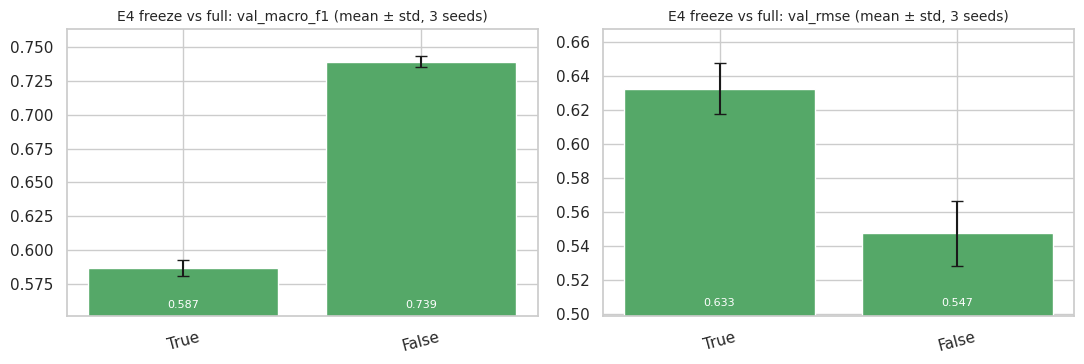

Current best config: {'text': 'raw', 'lr': 3e-05, 'class_weight': True, 'freeze': False}
freeze: False | lr: 3e-05


In [8]:
e4 = ex.sweep("E4", [dict(freeze=True, lr=1e-3), dict(freeze=False)])
plot_sweep(e4.fillna({"f1_std": 0, "rmse_std": 0}), "freeze", "E4 freeze vs full",
           FIG + "e4_bertweet_freeze.png", n_seeds=len(SEEDS), color="#55a868")
print("Current best config:", ex.best)
assert ex.best["freeze"] is False
print("freeze:", ex.best["freeze"], "| lr:", ex.best["lr"])


*Interpretation (E4):* the frozen encoder is far worse than full fine-tuning. The probe scores 0.5872 mean validation macro-F1 against 0.7389 for full fine-tuning. The final config stays freeze=False with learning rate 3e-5.


## Final model: learning curves and the single test evaluation
The final model is the best config with seed 42 (already trained above, so it is not retrained). Its learning curves show where it starts to overfit; early stopping restored the epoch with the best validation macro-F1. When `QUICK` is False, the model is evaluated once on test.


Final config: {'text': 'raw', 'lr': 3e-05, 'class_weight': True, 'freeze': False} | best epoch 5 | ckpt models/bertweet_ckpts/seed42_raw_lr3e-05_cw1_fr0.pt


,loss,val_loss,acc,val_acc,val_macro_f1,val_rmse
epoch,,,,,,
1,0.8546,0.6870,0.6370,0.7495,0.6917,0.5623
2,0.5736,0.6872,0.8030,0.7641,0.7181,0.5506
3,0.3862,0.8422,0.8723,0.7830,0.7303,0.5437
4,0.2618,0.9152,0.9184,0.7802,0.7265,0.5586
5,0.1697,1.1121,0.9541,0.7886,0.7432,0.5616


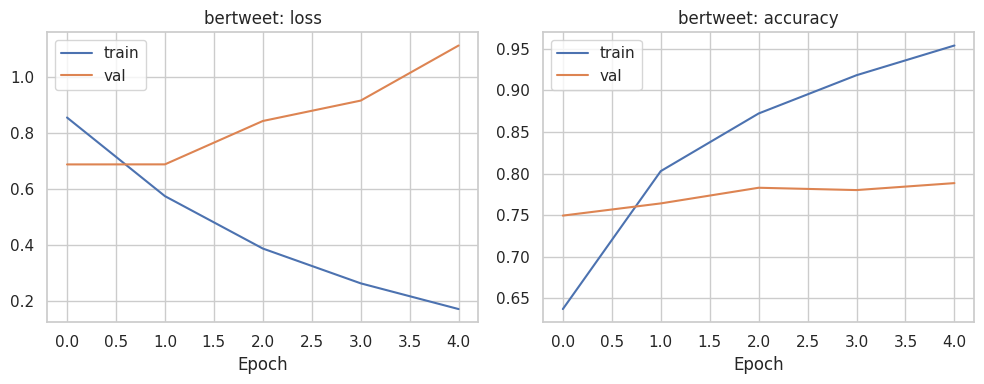

== bertweet | RMSE 0.5567 ==
              precision    recall  f1-score   support

    negative      0.597     0.566     0.581       152
     neutral      0.871     0.782     0.824       693
    positive      0.757     0.859     0.805       589

    accuracy                          0.791      1434
   macro avg      0.742     0.736     0.737      1434
weighted avg      0.796     0.791     0.791      1434



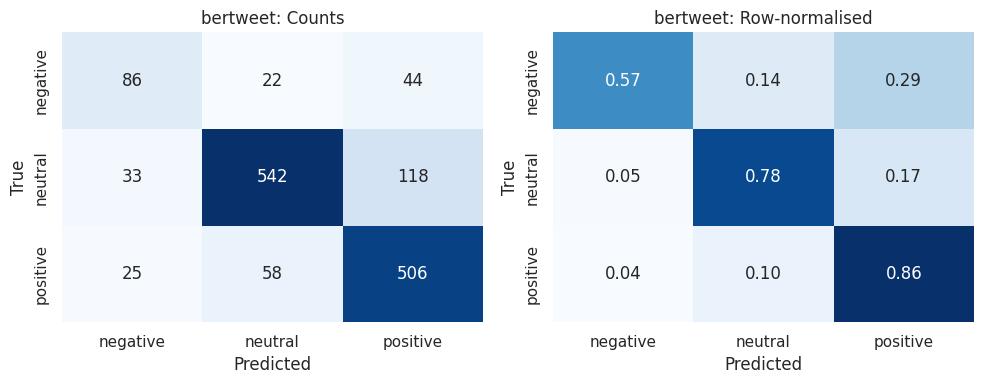

Wrote models/bertweet.pt and reports/predictions/bertweet.csv


In [9]:
cfg = dict(ex.best)
assert cfg.get("freeze") is False and float(cfg["lr"]) <= 5e-5
cache_key = (tuple(sorted(cfg.items())), 42)
assert cache_key in ex.cache, f"seed-42 run missing for best cfg {cfg}"
row, path, hist = ex.cache[cache_key]
print("Final config:", cfg, "| best epoch", row["best_epoch"], "| ckpt", path)
display(history_table(hist))

if QUICK:
    pass
else:
    plot_history(hist, MODEL)
    model, best_blob, path = ex.load_cached_model(cfg=cfg, seed=42, builder=model_builder)
    model.to(DEVICE)
    test_ds = BertStanceDataset(
        texts_for_variant(test, cfg["text"]), test["label_id"], tokenizer, MAX_LEN,
    )
    train_ds, val_ds = DS[cfg["text"]]
    _, _, test_dl = make_bert_loaders(
        train_ds, val_ds, test_ds, tokenizer=tokenizer, batch_size=BATCH, seed=42,
    )
    yp, ys, P = predict_bert(model, test_dl)
    evaluate(test["label"], yp, MODEL, y_score=ys)
    save_predictions(MODEL, test["tweet_id"], test["safe_text"], test["label"], yp, test["agreement"], ys)
    os.makedirs("models", exist_ok=True)
    torch.save(model.state_dict(), f"models/{MODEL}.pt")
    print("Wrote models/bertweet.pt and reports/predictions/bertweet.csv")
    free_model(model)


*Final test result:* the best configuration is raw text, learning rate 3e-5, class-weighted loss and full fine-tuning. On the held-out test set it scores macro-F1 0.7368, RMSE 0.5567 and accuracy 0.7908. Per-class F1 is 0.5811 (negative), 0.8243 (neutral) and 0.8051 (positive).

Compared with the other rows in reports/results.csv, BERTweet is ahead on macro-F1 by 0.0817 over tfidf_logreg (0.6551), by 0.0863 over bilstm_glove (0.6505), by 0.0826 over transformer_scratch (0.6542) and by 0.1320 over fasttext (0.6048). Its RMSE is lower (better) by 0.0271 against tfidf_logreg (0.5838) and by 0.0410 against bilstm_glove (0.5977). Accuracy is higher by 0.0725 against tfidf_logreg (0.7183) and by 0.0551 against bilstm_glove (0.7357).

The classification report shows that negative is the weakest class: precision 0.597, recall 0.566 and F1 0.581, against much higher F1 on neutral (0.824) and positive (0.805).

On the learning curve, validation loss is 0.6870 at epoch 1 and 0.6872 at epoch 2, then rises from epoch 3 (0.8422, 0.9152, 1.1121). Validation macro-F1 still reaches its best value at the last epoch (0.7432 at epoch 5 of 5), after 0.6917, 0.7181, 0.7303 and 0.7265. Early stopping therefore kept the final epoch.


## Optional: COVID-Twitter-BERT (validation only)
Off by default. One seed of `digitalepidemiologylab/covid-twitter-bert-v2` is trained with the best BERTweet config and compared on validation macro-F1 only. Test is not used.


In [10]:
RUN_COVID_BERT = False

if RUN_COVID_BERT:
    from src.bert_utils import COVID_BERT_NAME
    covid_tok = load_tokenizer(COVID_BERT_NAME)
    variant = ex.best["text"]
    covid_train = BertStanceDataset(
        texts_for_variant(train, variant), train["label_id"], covid_tok, MAX_LEN,
    )
    covid_val = BertStanceDataset(
        texts_for_variant(val, variant), val["label_id"], covid_tok, MAX_LEN,
    )
    tr_dl, va_dl, _ = make_bert_loaders(
        covid_train, covid_val, test_ds=None, tokenizer=covid_tok, batch_size=BATCH, seed=42,
    )
    covid = build_model(COVID_BERT_NAME, freeze_encoder=False)
    hist_c, best_c = fit_bert(
        covid, tr_dl, va_dl, val["label"],
        epochs=EPOCHS, lr=ex.best["lr"],
        weight_decay=0.01,
        class_weight_tensor=CW if ex.best["class_weight"] else None,
        patience=2, clip=1.0, warmup=0.1, verbose=True,
    )
    print("COVID-Twitter-BERT val:", best_c, "| BERTweet seed-42 val F1:", row["val_macro_f1"])
    display(history_table(hist_c))
    free_model(covid)
else:
    print("COVID-Twitter-BERT skipped (set RUN_COVID_BERT = True to run).")


COVID-Twitter-BERT skipped (set RUN_COVID_BERT = True to run).


## Summary
Fine-tuned BERTweet is the strongest model in reports/results.csv on this split: test macro-F1 0.7368, RMSE 0.5567 and accuracy 0.7908. Pretraining helps relative to the from-scratch Transformer (macro-F1 0.6542) and the BiLSTM (0.6505).

What mattered: full fine-tuning beat a frozen encoder by a wide margin (0.7389 against 0.5872 mean validation macro-F1). Learning rate 1e-5 was clearly worse than 2e-5 or 3e-5. Raw versus clean text, 2e-5 versus 3e-5, and class weighting versus no weighting were all within seed noise on validation; the higher means for raw, 3e-5 and class weighting were kept.

What did not matter much: the shared cleaner did not beat BERTweet raw input. A linear probe on a frozen encoder was not competitive.

Limitations: the test score is from one seed-42 run only, so test uncertainty across seeds was not measured. The best validation epoch was the last one (5 of 5), so longer training was not tested and possibly could raise validation macro-F1 further; a run with more epochs would check that.
